# todo
구조  
Model(name)  
- self.engine: 훈련 및 평가 engine (dataloader 포함)  
- self.model: 실제 모델  
- self.preprocess: resize 할때 padding 정보 반환  
  - type + shape으로 단일 이미지인지, batched_image인지 판단  
- self.__call__(): self.inference  
- self.inference: 전처리 + inference + 결과 처리  
- self.train(), val(): engine사용  
- self.eval(): data가 string이면 pycocotools, labels면 inference + 평가(이미지 2개)  

bbox 구현하고 segmentation은 이후 추가하기기

engine.__call__에서 input 확인해서 필요시 변환하기  
preprocess:  
1. 학습 image_size와 다르면 resize_padding with pad  
2. normalize  
postprocess:  
1. 좌표 복구
2. nms

평가에 필요한 요소  
1. image_id  
2. category_id  
3. bbox  
4. score  

현재 dataloader 입력 요소  
1. path
2. class_ids
3. coords
4. lengths


config에서 부터 모델 이름, 스케일, 버전 나눠서 가져오자.
ultralytics코드 참조

In [1]:
from src.cfg import *
from src.data import Dataset
from src.engine import *
from src.models import Model
import numpy as np
import tensorflow as tf        

class Engine():
    def __init__(self, **kwargs):
        # default
        self.cfg = Config(**kwargs)
        self.model = Model("temp.yaml")
        self.dataset = Dataset(self.cfg.data)

        # self.trainer = Trainer(self.cfg, self.dataset)
        self.validator = Validator(self.cfg, self.dataset)
        # self.evaluator = Evaluator(self.cfg, self.dataset)

    def loss(self, x, y):
        return tf.reduce_sum(x) - tf.reduce_sum(y)

    def on_epoch_start(self):
        self.dataloader.on_epoch_start()

    def on_epoch_end(self):
        self.dataloader.on_epoch_end()

2025-09-12 01:14:48.168479: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-12 01:14:48.200938: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-12 01:14:48.200964: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-12 01:14:48.201754: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-12 01:14:48.207302: I tensorflow/core/platform/cpu_feature_guar

In [2]:
engine = Engine(data="coco2", model="yolo11n.yaml")

yolo11n.yaml


Reading data for val: 100%|██████████| 5000/5000 [00:00<00:00, 450525.68it/s]

We read 4952 images without 48 images, which does not have labels.


In [3]:
engine.cfg.model

self.nc: 80
self.scales: 
    n: [0.5, 0.25, 1024]
    s: [0.5, 0.5, 1024]
    m: [0.5, 1.0, 512]
    l: [1.0, 1.0, 512]
    x: [1.0, 1.5, 512]
self.backbone: [[-1, 1, 'Conv', [64, 3, 2]], [-1, 1, 'Conv', [128, 3, 2]], [-1, 2, 'C3k2', [256, False, 0.25]], [-1, 1, 'Conv', [256, 3, 2]], [-1, 2, 'C3k2', [512, False, 0.25]], [-1, 1, 'Conv', [512, 3, 2]], [-1, 2, 'C3k2', [512, True]], [-1, 1, 'Conv', [1024, 3, 2]], [-1, 2, 'C3k2', [1024, True]], [-1, 1, 'SPPF', [1024, 5]], [-1, 2, 'C2PSA', [1024]]]
self.head: [[-1, 1, 'nn.Upsample', ['None', 2, 'nearest']], [[-1, 6], 1, 'Concat', [1]], [-1, 2, 'C3k2', [512, False]], [-1, 1, 'nn.Upsample', ['None', 2, 'nearest']], [[-1, 4], 1, 'Concat', [1]], [-1, 2, 'C3k2', [256, False]], [-1, 1, 'Conv', [256, 3, 2]], [[-1, 13], 1, 'Concat', [1]], [-1, 2, 'C3k2', [512, False]], [-1, 1, 'Conv', [512, 3, 2]], [[-1, 10], 1, 'Concat', [1]], [-1, 2, 'C3k2', [1024, True]], [[16, 19, 22], 1, 'Detect', ['nc']]]
self.name: yolo11
self.file: /home/ML/TF_YOLO/src/cfg/

In [4]:
import re
text = "yolo11n"
m = re.match(r"yolo(\d+)([nsml])", text)
print(m.groups())

('11', 'n')


In [3]:
from src.models.model import parse_model

layers, chs, strides = parse_model(engine.cfg.model)
layers, len(layers), len(chs)

yolo11


([[[0, 'conv', 1, [3, 16, 3, 2]]],
  [[1, 'conv', 1, [16, 32, 3, 2]]],
  [[2, 'c3k2', 1, [32, 64, 1, False, 0.25]]],
  [[3, 'conv', 1, [64, 64, 3, 2]]],
  [[4, 'c3k2', 1, [64, 128, 1, False, 0.25]]],
  [[5, 'conv', 1, [128, 128, 3, 2]]],
  [[6, 'c3k2', 1, [128, 128, 1, True]]],
  [[7, 'conv', 1, [128, 256, 3, 2]]],
  [[8, 'c3k2', 1, [256, 256, 1, True]]],
  [[9, 'sppf', 1, [256, 256, 5]]],
  [[10, 'c2psa', 1, [256, 256, 1]]],
  [[11, 'upsample', 1, [2, 'nearest']]],
  [[12, 'concat', 1, [1]]],
  [[13, 'c3k2', 1, [384, 128, 1, False]]],
  [[14, 'upsample', 1, [2, 'nearest']]],
  [[15, 'concat', 1, [1]]],
  [[16, 'c3k2', 1, [256, 64, 1, False]]],
  [[17, 'conv', 1, [64, 64, 3, 2]]],
  [[18, 'concat', 1, [1]]],
  [[19, 'c3k2', 1, [192, 128, 1, False]]],
  [[20, 'conv', 1, [128, 128, 3, 2]]],
  [[21, 'concat', 1, [1]]],
  [[22, 'c3k2', 1, [384, 256, 1, True]]],
  [[23, 'detect', 1, ['nc']]]],
 24,
 25)

In [4]:
for e in range(3):
    engine.validator()

Validate coco2 data: 100%|██████████| 310/310 [00:24<00:00, 12.77it/s]


Validate coco2 data: 100%|██████████| 310/310 [00:39<00:00,  7.93it/s]
Validate coco2 data: 100%|██████████| 310/310 [00:39<00:00,  7.92it/s]
Validate coco2 data: 100%|██████████| 310/310 [00:22<00:00, 13.86it/s]
Validate coco2 data: 100%|██████████| 310/310 [00:22<00:00, 13.91it/s]

Validate coco2 data: 100%|██████████| 310/310 [00:38<00:00,  8.04it/s]
Validate coco2 data: 100%|██████████| 310/310 [00:36<00:00,  8.39it/s]
Validate coco2 data: 100%|██████████| 310/310 [00:23<00:00, 13.24it/s]
Validate coco2 data: 100%|██████████| 310/310 [00:24<00:00, 12.80it/s]

In [ ]:
import numpy as np
a = [{1:np.zeros(1)}, {2:"123"}]
b = [a] * 2
c = b[0][0][1]
c = 2
b

In [ ]:
engine.trainer(engine.model)

In [ ]:
np.ones((3,3), dtype=np.float32)

In [ ]:
engine.evaluator(engine.model)

In [ ]:
engine.validator.process

0.11749780178070068


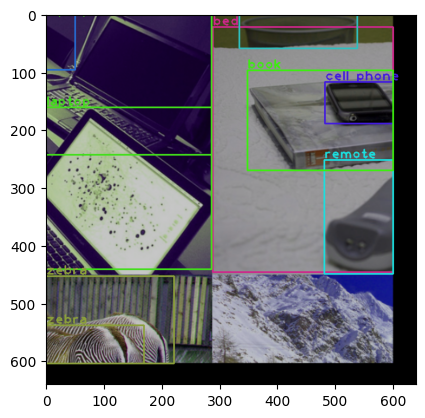

In [ ]:
from src.utils import Painter
from time import time as time

for e in range(1):
    st = time()
    for i, data in enumerate(engine.validator.dataloader):
        break
    et = time()
    print((et-st)/engine.cfg.epochs)

batch_image, batch_labels = data["image"], data["labels"]
idx = 0

image, labels = batch_image[idx], batch_labels[batch_labels[:, 0] == idx][:, 1:]
# image, mask = batch_image[idx], batch_labels[idx]

painter = Painter(engine.cfg.data.classes)

# painted_image = painter.draw_segment(image, class_ids, coords)
painted_image = painter.draw_box(image, labels[:, 0], labels[:, 1:])
painter.show(painted_image)

In [ ]:
import numpy as np
np.minimum(np.array([1,2]),np.array([0,3]))

array([0, 2])

In [ ]:
org_size = np.array([500, 400], np.float32)
left_top = (np.random.uniform(0.15, 0.25, 2) * org_size).astype(np.int32)
max_crop_size = org_size.astype(np.int32) - left_top
min_crop_size = ((1 - 0.25) * org_size).astype(np.int32)
image_size = np.minimum(min_crop_size, max_crop_size).astype(np.int32)

In [ ]:
max_crop_size, min_crop_size, image_size

In [ ]:
from multiprocessing import Process, Queue

def func(numbers, result_queue):
    new_numbers = [x ** 2 for x in numbers]
    result_queue.put(new_numbers)

data = [1,2,3,4,5]
result_queue = Queue()

processes = [Process(target=func, args=(data, result_queue)) for _ in range(3)]

for process in processes:
    process.start()

for process in processes:
    process.join()

results = [result_queue.get() for _ in processes]

In [ ]:
results

In [ ]:
from multiprocessing import Pool

def my_function(*args):
    result = sum(args)
    return result

with Pool(processes=2) as pool:
    inputs = [[1, 2, 2], [2, 3, 4], [2, 5, 6]]
    results = pool.starmap(my_function, inputs)

print("Results:", results)